In [3]:
import pandas as pd

titanic_df = pd.read_csv("update_titanic_data.csv")

titanic_df.head()

,Survived,initials,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,PStatus
0,0,Mr,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.2500,False,S,3
1,1,Mrs,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,True,C,1
2,1,Miss,"Heikkinen, Miss. Laina",female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,False,S,3
3,1,Mrs,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,True,S,1
4,0,Mr,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,False,S,3


In [4]:
titanic_df.drop(
    ["Name","initials"], axis=1, inplace= True
)

titanic_df.head()

,Survived,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,PStatus
0,0,male,22.0,1.0,0.0,A/5 21171,7.2500,False,S,3
1,1,female,38.0,1.0,0.0,PC 17599,71.2833,True,C,1
2,1,female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,False,S,3
3,1,female,35.0,1.0,0.0,113803,53.1000,True,S,1
4,0,male,35.0,0.0,0.0,373450,8.0500,False,S,3


### Label Encoding

Label Encoding is a technique that is used to convert categorical columns into numerical ones so that they can be fitted by machine learning models which only take numerical data. It is an important pre-processing step in a machine-learning project.

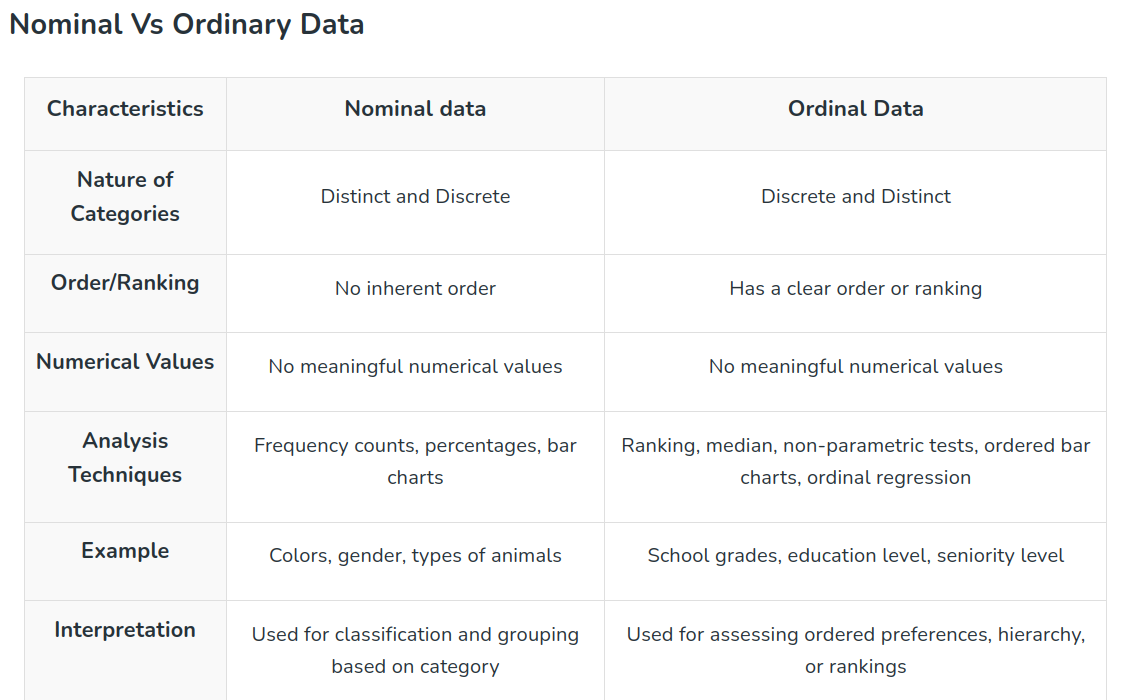

### Nominal Data

Data without natural order / rank

In [6]:
titanic_df.Gender

0        male
1      female
2      female
3      female
4        male
        ...  
831      male
832    female
833    female
834      male
835      male
Name: Gender, Length: 836, dtype: str

## One Hot Encoding

In [8]:
# Pandas
pd.get_dummies(
    titanic_df, columns=["Gender"], dtype=int
)

,Survived,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,PStatus,Gender_female,Gender_male
0,0,22.0,1.0,0.0,A/5 21171,7.2500,False,S,3,0,1
1,1,38.0,1.0,0.0,PC 17599,71.2833,True,C,1,1,0
2,1,26.0,0.0,0.0,STON/O2. 3101282,7.9250,False,S,3,1,0
3,1,35.0,1.0,0.0,113803,53.1000,True,S,1,1,0
4,0,35.0,0.0,0.0,373450,8.0500,False,S,3,0,1
...,...,...,...,...,...,...,...,...,...,...,...
831,0,27.0,0.0,0.0,211536,13.0000,False,S,2,0,1
832,1,19.0,0.0,0.0,112053,30.0000,True,S,1,1,0
833,0,21.5,1.0,2.0,W./C. 6607,23.4500,False,S,3,1,0
834,1,26.0,0.0,0.0,111369,30.0000,True,C,1,0,1


In [10]:
# Sci-kit Learn

# !pip install scikit-learn

from sklearn.preprocessing import OneHotEncoder

In [18]:
onehot_encoder = OneHotEncoder(sparse_output=False)

encoded_gender = onehot_encoder.fit_transform(titanic_df[["Gender"]])

In [14]:
encoded_gender

array([[0., 1.],
       [1., 0.],
       [1., 0.],
       ...,
       [1., 0.],
       [0., 1.],
       [0., 1.]], shape=(836, 2))

In [16]:
onehot_encoder.categories_

[array(['female', 'male'], dtype=object)]

In [17]:
onehot_encoder.inverse_transform(
    [[1,0],
     [0,1]]
)

array([['female'],
       ['male']], dtype=object)

In [22]:
df = pd.DataFrame(
    encoded_gender, columns=onehot_encoder.categories_[0], dtype=int
)

titanic_df = pd.concat([titanic_df, df], axis=1)
titanic_df.head()

,Survived,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,PStatus,female,male
0,0,male,22.0,1.0,0.0,A/5 21171,7.2500,False,S,3,0,1
1,1,female,38.0,1.0,0.0,PC 17599,71.2833,True,C,1,1,0
2,1,female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,False,S,3,1,0
3,1,female,35.0,1.0,0.0,113803,53.1000,True,S,1,1,0
4,0,male,35.0,0.0,0.0,373450,8.0500,False,S,3,0,1


In [25]:
# Pandas
pd.get_dummies(titanic_df, columns=["Gender", "Embarked"], dtype=int)

,Survived,Age,SibSp,Parch,Ticket,Fare,Cabin,PStatus,female,male,Gender_female,Gender_male,Embarked_C,Embarked_Q,Embarked_S
0,0,22.0,1.0,0.0,A/5 21171,7.2500,False,3,0,1,0,1,0,0,1
1,1,38.0,1.0,0.0,PC 17599,71.2833,True,1,1,0,1,0,1,0,0
2,1,26.0,0.0,0.0,STON/O2. 3101282,7.9250,False,3,1,0,1,0,0,0,1
3,1,35.0,1.0,0.0,113803,53.1000,True,1,1,0,1,0,0,0,1
4,0,35.0,0.0,0.0,373450,8.0500,False,3,0,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
831,0,27.0,0.0,0.0,211536,13.0000,False,2,0,1,0,1,0,0,1
832,1,19.0,0.0,0.0,112053,30.0000,True,1,1,0,1,0,0,0,1
833,0,21.5,1.0,2.0,W./C. 6607,23.4500,False,3,1,0,1,0,0,0,1
834,1,26.0,0.0,0.0,111369,30.0000,True,1,0,1,0,1,1,0,0


In [26]:
# Sklearn
onehot_encoder = OneHotEncoder(sparse_output=False)

encoded_data = onehot_encoder.fit_transform(titanic_df[["Gender","Embarked"]])


In [27]:
encoded_data

array([[0., 1., 0., 0., 1.],
       [1., 0., 1., 0., 0.],
       [1., 0., 0., 0., 1.],
       ...,
       [1., 0., 0., 0., 1.],
       [0., 1., 1., 0., 0.],
       [0., 1., 0., 1., 0.]], shape=(836, 5))

In [28]:
onehot_encoder.categories_

[array(['female', 'male'], dtype=object), array(['C', 'Q', 'S'], dtype=object)]

## Ordinal Data

Data with Order

In [29]:
titanic_df.Embarked

0      S
1      C
2      S
3      S
4      S
      ..
831    S
832    S
833    S
834    C
835    Q
Name: Embarked, Length: 836, dtype: str

In [32]:
# Pandas

titanic_df["Embarked_Enc"], rule = titanic_df.Embarked.factorize(sort = False)

In [33]:
titanic_df

,Survived,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,PStatus,female,male,Embarked_Enc
0,0,male,22.0,1.0,0.0,A/5 21171,7.2500,False,S,3,0,1,0
1,1,female,38.0,1.0,0.0,PC 17599,71.2833,True,C,1,1,0,1
2,1,female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,False,S,3,1,0,0
3,1,female,35.0,1.0,0.0,113803,53.1000,True,S,1,1,0,0
4,0,male,35.0,0.0,0.0,373450,8.0500,False,S,3,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
831,0,male,27.0,0.0,0.0,211536,13.0000,False,S,2,0,1,0
832,1,female,19.0,0.0,0.0,112053,30.0000,True,S,1,1,0,0
833,0,female,21.5,1.0,2.0,W./C. 6607,23.4500,False,S,3,1,0,0
834,1,male,26.0,0.0,0.0,111369,30.0000,True,C,1,0,1,1


In [34]:
rule

Index(['S', 'C', 'Q'], dtype='str')

In [42]:
# Sklearn 
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

In [44]:
label_encoder = OrdinalEncoder()
encoded_embarked = label_encoder.fit_transform(
    titanic_df[["Embarked"]]
)

In [45]:
encoded_embarked[:10]

array([[2.],
       [0.],
       [2.],
       [2.],
       [2.],
       [1.],
       [2.],
       [2.],
       [2.],
       [0.]])

In [47]:
label_encoder.categories_

[array(['C', 'Q', 'S'], dtype=object)]

In [51]:
import numpy as np

label_encoder.inverse_transform(
    np.array([1,2,2,0,0,1]).reshape(-1, 1)
)

array([['Q'],
       ['S'],
       ['S'],
       ['C'],
       ['C'],
       ['Q']], dtype=object)

In [54]:
titanic_df["Cabin"] = titanic_df.Cabin.astype(int)
new_titanic_df = titanic_df.drop(
    ["Gender","Ticket", "Embarked"], axis= 1,
)
new_titanic_df

,Survived,Age,SibSp,Parch,Fare,Cabin,PStatus,female,male,Embarked_Enc
0,0,22.0,1.0,0.0,7.2500,0,3,0,1,0
1,1,38.0,1.0,0.0,71.2833,1,1,1,0,1
2,1,26.0,0.0,0.0,7.9250,0,3,1,0,0
3,1,35.0,1.0,0.0,53.1000,1,1,1,0,0
4,0,35.0,0.0,0.0,8.0500,0,3,0,1,0
...,...,...,...,...,...,...,...,...,...,...
831,0,27.0,0.0,0.0,13.0000,0,2,0,1,0
832,1,19.0,0.0,0.0,30.0000,1,1,1,0,0
833,0,21.5,1.0,2.0,23.4500,0,3,1,0,0
834,1,26.0,0.0,0.0,30.0000,1,1,0,1,1


In [55]:
new_titanic_df.to_csv(
    "final_titanic_data.csv", index=False
)